# BONUS EXERCISE   
**Names:** Mariem Memmi and Ilhame Sarbane  

## Goals
1. Read two CSV files  
2. Output statistics (min, max, count, std, mean) for each column in each file
3. Merge both files on Time as a common key
4. Train a Linear Regression model with Energy delta[Wh] as the target variable  
5. Output the RÂ² score
6. Plot a correlation matrix (target + features)
7. Create a scatter plot of KWH vs GHI with a regression line.

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from pathlib import Path

In [2]:
DATA_DIR = Path("data")
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

print("DATA:", DATA_DIR.resolve())
print("OUT :", OUT_DIR.resolve())

DATA: C:\Users\Akbour\Desktop\little project\data
OUT : C:\Users\Akbour\Desktop\little project\outputs


## 1) Load CSV files

### File 1

In [3]:
df1 = pd.read_csv(DATA_DIR / "file1.csv", sep=";")
df1.head()

,Time,Energy delta[Wh]
0,2017-01-01 00:00:00,0
1,2017-01-01 00:15:00,0
2,2017-01-01 00:30:00,0
3,2017-01-01 00:45:00,0
4,2017-01-01 01:00:00,0


In [4]:
df2 = pd.read_csv(DATA_DIR / "file2.csv")
df2.head()

,Time,GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
0,2021-08-07 19:30:00,0.0,19.8,1005,70,2.0,0.0,0.0,100,0,0,915,0.00,4,19,8
1,2017-01-14 20:45:00,0.0,-1.2,1005,91,3.6,0.0,0.0,28,0,0,480,0.00,2,20,1
2,2018-08-13 06:15:00,75.0,17.3,1010,70,2.3,0.0,0.0,94,1,180,900,0.20,4,6,8
3,2018-09-10 07:00:00,80.7,16.2,1021,69,2.6,0.0,0.0,100,1,165,780,0.21,4,7,9
4,2020-05-07 17:00:00,37.7,12.9,1021,59,3.1,0.0,0.0,71,1,840,930,0.90,3,17,5


## 2) Statistics for both files

In [5]:
stats1 = df1.select_dtypes("number").agg(["min","max","count","std","mean"]).T
print("=== file1 stats ===")
print(stats1)

stats2 = df2.select_dtypes("number").agg(["min","max","count","std","mean"]).T
print("\n=== file2 stats ===")
print(stats2)

# save to csv
stats1.to_csv(OUT_DIR / "stats_file1.csv")
stats2.to_csv(OUT_DIR / "stats_file2.csv")

=== file1 stats ===
                  min      max     count          std        mean
Energy delta[Wh]  0.0  50000.0  196776.0  1157.490585  578.024525

=== file2 stats ===
                          min         max     count          std         mean
GHI                       0.0    83500.00  196781.0   253.573447    33.384912
temp                    -16.6    21300.00  196781.0    83.839240    10.176997
pressure                977.0  1030000.00  196781.0  5153.589267  1041.270509
humidity                 22.0    94000.00  196781.0   342.819971    81.424548
wind_speed                0.0     4900.00  196781.0    16.630997     4.017939
rain_1h                   0.0        8.09  196781.0     0.278910     0.066033
snow_1h                   0.0        2.82  196781.0     0.069709     0.007147
clouds_all                0.0    98000.00  196781.0   347.964106    67.461676
isSun                     0.0     1000.00  196781.0     3.225301     0.530112
sunlightTime              0.0   840000.00  1967

## 3) Merge datasets on Time

In [6]:
# convert to datetime
df1["Time"] = pd.to_datetime(df1["Time"])
df2["Time"] = pd.to_datetime(df2["Time"])

# merge 
merged_df = pd.merge(df1, df2, on="Time", how="inner").sort_values("Time")
print("Merged shape:", merged_df.shape)
merged_df.head()

Merged shape: (196776, 17)


,Time,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
0,2017-01-01 00:00:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
1,2017-01-01 00:15:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
2,2017-01-01 00:30:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
3,2017-01-01 00:45:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
4,2017-01-01 01:00:00,0,0.0,1.7,1020,100,5.2,0.0,0.0,100,0,0,450,0.0,4,1,1


## 4) Linear Regression Model
Target: Energy delta[Wh]  
Features: all other columns (with encoding for hour, month, weather_type)

Split: 80% train / 20% test

In [7]:
y = merged_df["Energy delta[Wh]"]
X = merged_df.drop(columns=["Energy delta[Wh]", "Time"]).copy()

# cyclical encoding for hour and month
X["hour_sin"] = np.sin(2 * np.pi * X["hour"] / 24)
X["hour_cos"] = np.cos(2 * np.pi * X["hour"] / 24)
m = X["month"] - 1
X["month_sin"] = np.sin(2*np.pi*m/12)
X["month_cos"] = np.cos(2*np.pi*m/12)
X = X.drop(columns=["hour", "month"])

# one-hot encode weather_type
X = pd.get_dummies(X, columns=["weather_type"], drop_first=True)

# split data
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# train model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
model_r2 = r2_score(y_test, y_pred)
print("RÂ² score =", model_r2)

RÂ² score = 0.6763455912329046


The model got RÂ² = 0.68 which means it explains about 68% of the variance in energy generation.

## 5) Correlation Matrix

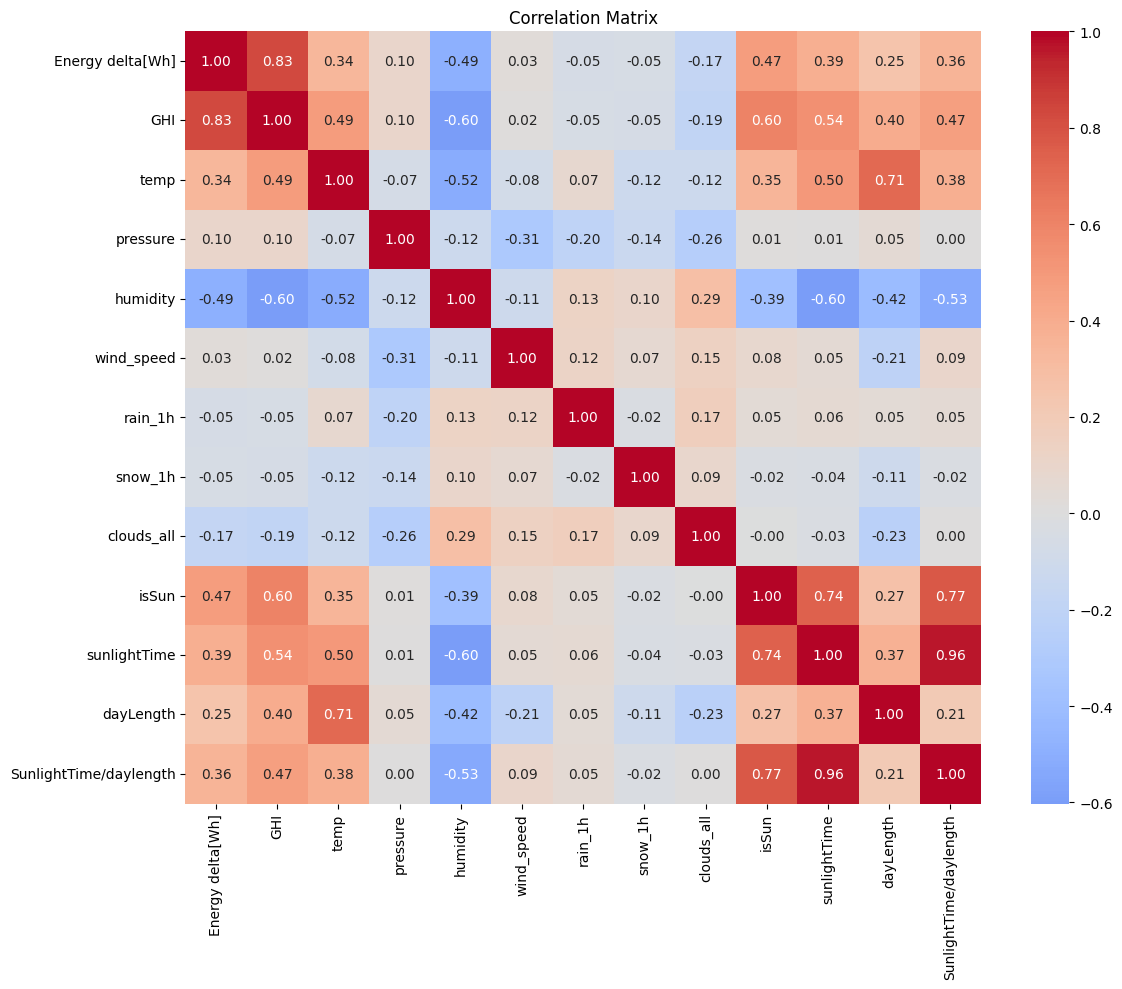

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = ["Energy delta[Wh]", "GHI", "temp", "pressure", "humidity", 
             "wind_speed", "rain_1h", "snow_1h", "clouds_all", "isSun", 
             "sunlightTime", "dayLength", "SunlightTime/daylength"]

corr_matrix = merged_df[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(OUT_DIR / "correlation_matrix.png", dpi=300)
plt.show()

GHI has the strongest correlation with energy generation which makes sense since it's solar irradiance. Cloud coverage is negatively correlated.

## 6) Scatter Plot: KWH vs GHI

C:\Users\Akbour\AppData\Local\Temp\ipykernel_19352\2864621499.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(OUT_DIR / "kwh_vs_ghi_scatter.png", dpi=300)


C:\Users\Akbour\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


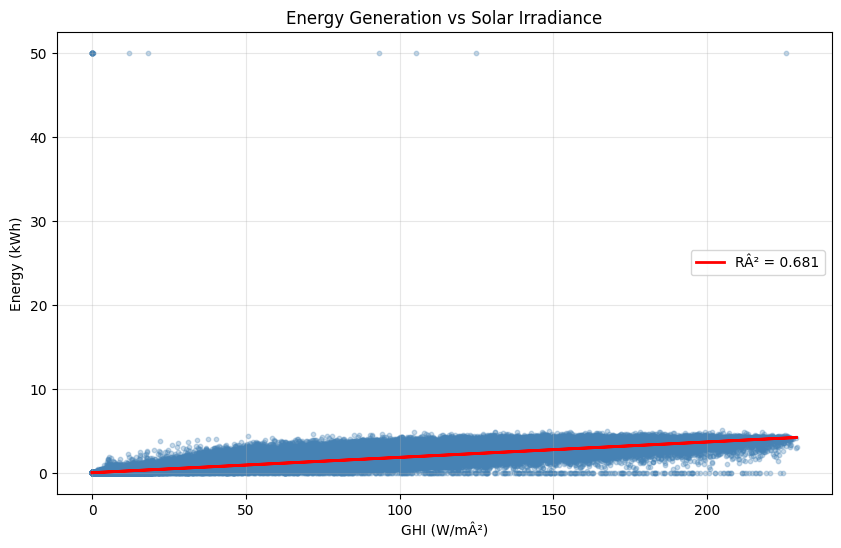

RÂ² = 0.6809


In [9]:
merged_df["KWH"] = merged_df["Energy delta[Wh]"] / 1000

X_ghi = merged_df["GHI"].values.reshape(-1, 1)
y_kwh = merged_df["KWH"].values

lr_scatter = LinearRegression()
lr_scatter.fit(X_ghi, y_kwh)
y_pred_line = lr_scatter.predict(X_ghi)

r2_ghi_kwh = r2_score(y_kwh, y_pred_line)

plt.figure(figsize=(10, 6))
plt.scatter(merged_df["GHI"], merged_df["KWH"], alpha=0.3, s=10, color='steelblue')
plt.plot(merged_df["GHI"], y_pred_line, color='red', linewidth=2, label=f'RÂ² = {r2_ghi_kwh:.3f}')
plt.xlabel("GHI (W/mÂ²)")
plt.ylabel("Energy (kWh)")
plt.title("Energy Generation vs Solar Irradiance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(OUT_DIR / "kwh_vs_ghi_scatter.png", dpi=300)
plt.show()

print(f"RÂ² = {r2_ghi_kwh:.4f}")

## Summary

The analysis shows that:
- Successfully merged 196,776 records from both files
- Linear regression model achieved RÂ² = 0.676 (68% variance explained)
- GHI (solar irradiance) is the most important predictor of energy generation
- Cloud coverage has negative correlation with energy production
- The model performs decently but could be improved with more advanced techniques